# Fase 4: Model Training — Dual-Input Cross-Lingual

Notebook ini membangun, melatih, dan menyimpan model **Dual-Layer Cross-Lingual** menggunakan
fitur struktural (29 dim) dan semantic embeddings dari MiniLM (384 dim).

**Input:**
- `data_cleaned.parquet` — untuk referensi `id` dan `source` (label)
- `features_structural.parquet` — Fitur struktural 29 dimensi
- `feature_config.json` — Urutan kolom fitur kanonik
- `minilm_embeddings.npy` — Semantic embeddings 384 dimensi (L2-normalized)
- `minilm_id_index.npy` — Mapping ID teks untuk embeddings

**Output:**
- `best_model.keras` — Model klasifikasi terbaik (Keras)
- `structural_scaler.pkl` — StandardScaler yang di-fit pada data training
- `test_data.npz` — Test split untuk evaluasi di Notebook 5
- `inference_config.json` — Optimal threshold dan konfigurasi inference

> **Catatan Penting:**  
> Split data dilakukan berdasarkan **ID unik** (`id` kolom), bukan per-baris.  
> Ini memastikan teks human & AI dari instruksi yang sama SELALU di split yang sama,
> menghindari *data leakage* yang menyebabkan akurasi palsu 99%.


In [1]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import gc

# --- GPU Configuration ---
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU Terdeteksi: {[g.name for g in gpus]}")
    except RuntimeError as e:
        print(e)
else:
    print("GPU tidak terdeteksi. Training berjalan di CPU (akan lebih lambat).")

print(f"TensorFlow version: {tf.__version__}")


I0000 00:00:1781337721.963968   90015 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781337722.289351   90015 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781337726.269877   90015 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPU Terdeteksi: ['/physical_device:GPU:0']
TensorFlow version: 2.21.0


## 1. Load Data & Group-Based Split

### Mengapa Kita Harus Split Berdasarkan ID (Group Split)?

Dataset ini memiliki struktur **berpasangan**: setiap `id` memiliki satu versi teks manusia
dan satu versi teks AI dari **instruksi yang sama**.

Jika kita split secara acak per-baris:
- Versi human dari "jelaskan fotosintesis" → masuk **train**
- Versi AI dari "jelaskan fotosintesis" → masuk **test**

Model akan belajar mencocokkan **topik/konten** bukan **gaya menulis**,
menghasilkan akurasi 99% yang merupakan *data leakage*, bukan kemampuan deteksi nyata.

**Solusi:** Kita kumpulkan semua `id` unik, split ID-nya terlebih dahulu (70/15/15),
lalu assign seluruh baris yang ber-id sama ke split yang sama.


In [ ]:
# -------------------------------------------------------
# Widget konfigurasi jumlah data
# -------------------------------------------------------
style = {'description_width': 'initial'}
sample_size_widget = widgets.IntSlider(
    value=100000,
    min=10000,
    max=1000000,
    step=10000,
    description='Max Baris (dari embedding):',
    style=style,
    layout=widgets.Layout(width='620px'),
    readout_format=','
)

btn_load_data = widgets.Button(
    description='Load & Group-Split Data',
    button_style='primary',
    icon='download',
    layout=widgets.Layout(width='240px', height='38px')
)

out_load = widgets.Output()

display(widgets.HBox([sample_size_widget]), btn_load_data, out_load)

# Global variables untuk menyimpan data
global_X_struct_train = None
global_X_struct_val   = None
global_X_struct_test  = None
global_X_embed_train  = None
global_X_embed_val    = None
global_X_embed_test   = None
global_y_train        = None
global_y_val          = None
global_y_test         = None
global_scaler         = None  # StandardScaler fit on train ONLY

def load_and_split_data(b):
    global global_X_struct_train, global_X_struct_val, global_X_struct_test
    global global_X_embed_train, global_X_embed_val, global_X_embed_test
    global global_y_train, global_y_val, global_y_test, global_scaler

    with out_load:
        clear_output()
        print("=" * 60)
        print("  MEMUAT DAN MEMPROSES DATA")
        print("=" * 60)

        # --- 1. Load embedding IDs ---
        print("\n[1/6] Memuat embedding index...")
        if not os.path.exists("minilm_embeddings.npy") or not os.path.exists("minilm_id_index.npy"):
            print("ERROR: File embeddings tidak ditemukan. Jalankan Notebook 3 terlebih dahulu.")
            return

        full_ids = np.load("minilm_id_index.npy", allow_pickle=True)
        print(f"     Total embedding tersedia: {len(full_ids):,}")

        # --- 2. Subsample jika perlu ---
        sample_size = sample_size_widget.value
        if sample_size < len(full_ids):
            print(f"\n[2/6] Subsampling {sample_size:,} dari {len(full_ids):,} baris...")
            np.random.seed(42)
            sample_indices = np.random.choice(len(full_ids), sample_size, replace=False)
            sample_indices.sort()
            full_emb_mmap = np.load("minilm_embeddings.npy", mmap_mode='r')
            embeddings = full_emb_mmap[sample_indices].copy()
            ids = full_ids[sample_indices]
        else:
            print(f"\n[2/6] Memuat seluruh {len(full_ids):,} embeddings...")
            embeddings = np.load("minilm_embeddings.npy")
            ids = full_ids

        # --- 3. Load fitur struktural ---
        print("\n[3/6] Memuat fitur struktural...")
        if not os.path.exists("features_structural.parquet") or not os.path.exists("feature_config.json"):
            print("ERROR: File fitur struktural tidak ditemukan. Jalankan Notebook 2 terlebih dahulu.")
            return

        with open("feature_config.json", "r") as f:
            config = json.load(f)
        feature_cols = config.get("active_features", config.get("all_features_canonical", []))
        print(f"     Fitur aktif: {len(feature_cols)} kolom")

        df_struct = pd.read_parquet("features_structural.parquet")
        print(f"     Structural parquet: {df_struct.shape}")

        # --- 4. Merge berdasarkan row_id ---
        print("\n[4/6] Menggabungkan embedding + fitur + label...")
        # Normalisasi tipe ID ke string agar merge konsisten antar notebook
        # (minilm_id_index sekarang berisi row_id = id_source)
        ids_str       = np.array([str(i) for i in ids])
        df_struct["row_id"] = df_struct["id"].astype(str) + "_" + df_struct["source"].astype(str)
        df_emb = pd.DataFrame({"row_id": ids_str, "emb_index": np.arange(len(ids_str))})
        df_merged = df_emb.merge(df_struct, on="row_id", how="inner")

        if len(df_merged) == 0:
            print("ERROR: Tidak ada ID yang cocok antara embeddings dan structural features!")
            print("   Pastikan Notebook 2 dan 3 menggunakan parquet yang sama (data_cleaned.parquet).")
            return

        # Ambil data yang sudah di-join
        valid_emb_idx    = df_merged["emb_index"].values
        X_embed_all      = embeddings[valid_emb_idx]          # (N, 384)
        X_struct_all_raw = df_merged[feature_cols].values.astype(np.float32)  # (N, 29)
        y_all            = (df_merged["source"] == "ai").astype(int).values
        id_all           = df_merged["id"].values

        print(f"     Valid samples setelah merge: {len(y_all):,}")
        print(f"     Distribusi: Human={( y_all==0).sum():,} | AI={(y_all==1).sum():,}")

        # --- 5. GROUP-BASED SPLIT (berdasarkan unique ID) ---
        print("\n[5/6] Melakukan Group-Based Split (70/15/15 berdasarkan ID unik)...")

        # Kumpulkan ID unik (setiap ID muncul 2x: human + AI)
        unique_ids = np.unique(id_all)
        print(f"     ID unik ditemukan: {len(unique_ids):,}")

        # Split ID: 70% train, 15% val, 15% test
        ids_train, ids_temp = train_test_split(
            unique_ids, test_size=0.30, random_state=42
        )
        ids_val, ids_test = train_test_split(
            ids_temp, test_size=0.50, random_state=42
        )

        print(f"     ID di train : {len(ids_train):,}")
        print(f"     ID di val   : {len(ids_val):,}")
        print(f"     ID di test  : {len(ids_test):,}")

        # Assign baris ke split berdasarkan ID-nya
        ids_train_set = set(ids_train)
        ids_val_set   = set(ids_val)
        ids_test_set  = set(ids_test)

        mask_train = np.array([i in ids_train_set for i in id_all])
        mask_val   = np.array([i in ids_val_set   for i in id_all])
        mask_test  = np.array([i in ids_test_set  for i in id_all])

        X_struct_raw_train = X_struct_all_raw[mask_train]
        X_struct_raw_val   = X_struct_all_raw[mask_val]
        X_struct_raw_test  = X_struct_all_raw[mask_test]

        X_embed_train = X_embed_all[mask_train]
        X_embed_val   = X_embed_all[mask_val]
        X_embed_test  = X_embed_all[mask_test]

        y_train = y_all[mask_train]
        y_val   = y_all[mask_val]
        y_test  = y_all[mask_test]

        print(f"\n     Baris train : {len(y_train):,} (Human={( y_train==0).sum():,} | AI={(y_train==1).sum():,})")
        print(f"     Baris val   : {len(y_val):,}   (Human={( y_val==0).sum():,}   | AI={(y_val==1).sum():,})")
        print(f"     Baris test  : {len(y_test):,}  (Human={( y_test==0).sum():,}  | AI={(y_test==1).sum():,})")

        # --- 6. Fit StandardScaler pada TRAIN ONLY ---
        print("\n[6/6] Fitting StandardScaler pada training data...")
        scaler = StandardScaler()
        X_struct_train = scaler.fit_transform(X_struct_raw_train).astype(np.float32)
        X_struct_val   = scaler.transform(X_struct_raw_val).astype(np.float32)
        X_struct_test  = scaler.transform(X_struct_raw_test).astype(np.float32)

        print(f"     Scaler fit selesai.")
        print(f"     Contoh mean scaler (5 fitur pertama): {scaler.mean_[:5].round(4)}")
        print(f"     Contoh std scaler (5 fitur pertama) : {scaler.scale_[:5].round(4)}")

        # Simpan ke global variables
        global_X_struct_train = X_struct_train
        global_X_struct_val   = X_struct_val
        global_X_struct_test  = X_struct_test
        global_X_embed_train  = X_embed_train
        global_X_embed_val    = X_embed_val
        global_X_embed_test   = X_embed_test
        global_y_train        = y_train
        global_y_val          = y_val
        global_y_test         = y_test
        global_scaler         = scaler

        # Simpan scaler segera agar bisa dipakai Notebook 5 (inference)
        with open("structural_scaler.pkl", "wb") as f:
            pickle.dump(scaler, f)
        print("\nstructural_scaler.pkl disimpan.")

        # Simpan test data segera agar Notebook 5 bisa load tanpa training ulang
        np.savez(
            "test_data.npz",
            X_test_struct  = X_struct_test,
            X_test_embed   = X_embed_test,
            y_test         = y_test,
            feature_cols   = np.array(feature_cols)
        )
        print("test_data.npz disimpan.")

        # Cleanup memori
        del df_struct, df_emb, df_merged, embeddings, full_ids
        gc.collect()

        print("\n" + "=" * 60)
        print("  DATA SIAP Lanjutkan ke Bagian 2 (Training)")
        print("=" * 60)

btn_load_data.on_click(load_and_split_data)


Button(button_style='primary', description='Load & Group-Split Data', icon='download', layout=Layout(height='3…

Output()

## 2. Arsitektur Model Dual-Input

```
Input Structural (29 dim, sudah di-StandardScaler)
    → Dense(64, ReLU) → BatchNorm → Dropout
    → Dense(32, ReLU)
    ↘
                        Concatenate (32 + 32 = 64 dim)
                            → Dense(128, ReLU) → Dropout
                            → Dense(64, ReLU) → Dropout
                            → Dense(1, Sigmoid) → P(AI)
    ↗
Input Embedding (384 dim, L2-normalized)
    → Dense(64, ReLU) → BatchNorm → Dropout
    → Dense(32, ReLU)
```

Arsitektur ini **memproses setiap branch secara terpisah** sebelum digabung,
memastikan model belajar representasi yang baik dari structural features
(bukan tenggelam oleh 384-dim embedding).


In [3]:
# -------------------------------------------------------
# Fungsi pembuat model Dual-Input
# -------------------------------------------------------
def build_model(
    struct_dim    = 29,
    embed_dim     = 384,
    branch_units  = 64,
    merge_units1  = 128,
    merge_units2  = 64,
    dropout_rate  = 0.4,
    learning_rate = 3e-4
):
    """
    Dual-Input model dengan per-branch processing sebelum merge.
    Structural features di-scale sebelum masuk ke sini (StandardScaler diluar model).
    Embedding features sudah L2-normalized dari Notebook 3.
    """

    # --- Branch A: Structural Features ---
    input_struct = tf.keras.Input(shape=(struct_dim,), name="structural")
    x_s = tf.keras.layers.Dense(branch_units, activation="relu")(input_struct)
    x_s = tf.keras.layers.BatchNormalization()(x_s)
    x_s = tf.keras.layers.Dropout(dropout_rate)(x_s)
    x_s = tf.keras.layers.Dense(branch_units // 2, activation="relu")(x_s)

    # --- Branch B: Semantic Embeddings ---
    input_embed = tf.keras.Input(shape=(embed_dim,), name="embedding")
    x_e = tf.keras.layers.Dense(branch_units, activation="relu")(input_embed)
    x_e = tf.keras.layers.BatchNormalization()(x_e)
    x_e = tf.keras.layers.Dropout(dropout_rate)(x_e)
    x_e = tf.keras.layers.Dense(branch_units // 2, activation="relu")(x_e)

    # --- Merge ---
    merged = tf.keras.layers.Concatenate()([x_s, x_e])

    x = tf.keras.layers.Dense(merge_units1, activation="relu")(merged)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    x = tf.keras.layers.Dense(merge_units2, activation="relu")(x)
    x = tf.keras.layers.Dropout(dropout_rate * 0.5)(x)

    output = tf.keras.layers.Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(inputs=[input_struct, input_embed], outputs=output)

    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=learning_rate,
        weight_decay=1e-5
    )

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.AUC(name="roc_auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )

    return model


# -------------------------------------------------------
# Live Plot Callback
# -------------------------------------------------------
class LivePlotCallback(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.epochs = []
        self.history_dict = {
            'loss': [], 'val_loss': [],
            'accuracy': [], 'val_accuracy': [],
            'roc_auc': [], 'val_roc_auc': [],
            'precision': [], 'val_precision': [],
            'recall': [], 'val_recall': []
        }

    def on_train_begin(self, logs=None):
        plt.ion()
        self.fig, self.axes = plt.subplots(1, 3, figsize=(18, 5))
        self.display_id = display(self.fig, display_id=True)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        self.epochs.append(epoch + 1)
        for key in self.history_dict.keys():
            self.history_dict[key].append(logs.get(key, 0))

        for ax in self.axes:
            ax.clear()

        # Loss
        self.axes[0].plot(self.epochs, self.history_dict['loss'],     label='Train Loss', color='#4a90e2')
        self.axes[0].plot(self.epochs, self.history_dict['val_loss'], label='Val Loss',   color='#e27a4a')
        self.axes[0].set_title('Binary Cross-Entropy Loss', fontweight='bold')
        self.axes[0].set_xlabel('Epoch'); self.axes[0].legend(); self.axes[0].grid(alpha=0.3)

        # Accuracy
        self.axes[1].plot(self.epochs, self.history_dict['accuracy'],     label='Train Acc', color='#27ae60')
        self.axes[1].plot(self.epochs, self.history_dict['val_accuracy'], label='Val Acc',   color='#c0392b')
        self.axes[1].set_title('Accuracy', fontweight='bold')
        self.axes[1].set_xlabel('Epoch'); self.axes[1].set_ylim([0.4, 1.0])
        self.axes[1].legend(); self.axes[1].grid(alpha=0.3)

        # ROC AUC
        self.axes[2].plot(self.epochs, self.history_dict['roc_auc'],     label='Train AUC', color='#8e44ad')
        self.axes[2].plot(self.epochs, self.history_dict['val_roc_auc'], label='Val AUC',   color='#d35400')
        self.axes[2].set_title('ROC AUC', fontweight='bold')
        self.axes[2].set_xlabel('Epoch'); self.axes[2].set_ylim([0.4, 1.0])
        self.axes[2].legend(); self.axes[2].grid(alpha=0.3)

        self.fig.tight_layout()
        self.display_id.update(self.fig)

    def on_train_end(self, logs=None):
        plt.ioff()

print("Fungsi `build_model` dan `LivePlotCallback` siap.")


Fungsi `build_model` dan `LivePlotCallback` siap.


## 3. Konfigurasi Hyperparameter & Training

Konfigurasi parameter training. Model terbaik (berdasarkan **val_roc_auc**) otomatis disimpan ke `best_model.keras`.

> **Class Weight:** Diaktifkan secara otomatis jika distribusi train tidak seimbang (ratio > 1.5:1).


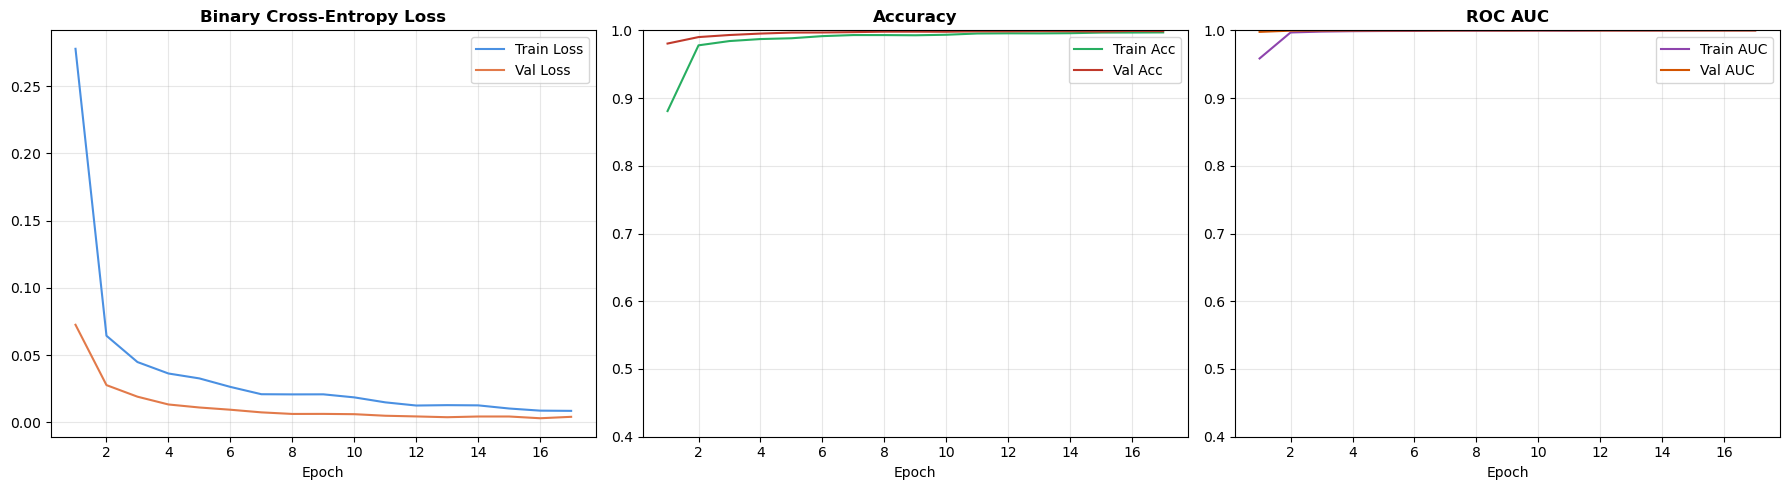

In [ ]:
# -------------------------------------------------------
# Widget konfigurasi training
# -------------------------------------------------------
style_w = {'description_width': 'initial'}

w_branch   = widgets.Dropdown(options=[32, 64, 128], value=64,
                               description='Branch Units:', style=style_w)
w_merge1   = widgets.Dropdown(options=[64, 128, 256], value=128,
                               description='Merge Layer 1:', style=style_w)
w_merge2   = widgets.Dropdown(options=[32, 64, 128], value=64,
                               description='Merge Layer 2:', style=style_w)
w_drop     = widgets.FloatSlider(value=0.4, min=0.1, max=0.6, step=0.05,
                                  description='Dropout:', style=style_w,
                                  layout=widgets.Layout(width='380px'))
w_lr       = widgets.FloatLogSlider(value=3e-4, base=10, min=-5, max=-2, step=0.25,
                                     description='Learning Rate:', style=style_w,
                                     layout=widgets.Layout(width='380px'))
w_epochs   = widgets.IntSlider(value=30, min=5, max=100, step=5,
                                description='Epochs:', style=style_w,
                                layout=widgets.Layout(width='380px'))
w_batch    = widgets.Dropdown(options=[64, 128, 256, 512], value=128,
                               description='Batch Size:', style=style_w)
w_patience = widgets.IntSlider(value=7, min=3, max=20, step=1,
                                description='Early Stopping Patience:', style=style_w,
                                layout=widgets.Layout(width='380px'))

btn_train  = widgets.Button(description='Mulai Training', button_style='success',
                             icon='play', layout=widgets.Layout(width='220px', height='40px'))
out_train  = widgets.Output()

display(widgets.VBox([
    widgets.HTML("<b style='font-size:14px'>Konfigurasi Model</b>"),
    widgets.HBox([w_branch, w_merge1, w_merge2, w_batch]),
    widgets.HTML("<b style='font-size:14px'>Konfigurasi Training</b>"),
    widgets.HBox([w_drop, w_lr]),
    widgets.HBox([w_epochs, w_patience]),
    widgets.HBox([btn_train]),
    out_train
]))


# -------------------------------------------------------
# Training Function
# -------------------------------------------------------
def start_training(b):
    with out_train:
        clear_output()

        if global_X_struct_train is None:
            print("Load data terlebih dahulu dengan klik 'Load & Group-Split Data'!")
            return

        batch_size    = w_batch.value
        n_train       = len(global_y_train)
        n_val         = len(global_y_val)
        struct_dim    = global_X_struct_train.shape[1]
        embed_dim     = global_X_embed_train.shape[1]

        print("=" * 65)
        print("  MEMULAI TRAINING")
        print("=" * 65)
        print(f"  Train samples    : {n_train:,} | Val samples: {n_val:,}")
        print(f"  Structural dim   : {struct_dim} | Embedding dim: {embed_dim}")
        print(f"  Batch size       : {batch_size}")
        print(f"  Epochs (max)     : {w_epochs.value}")
        print(f"  Early stopping   : patience={w_patience.value}")

        # --- Hitung class weights (untuk menangani imbalance) ---
        n_human = (global_y_train == 0).sum()
        n_ai    = (global_y_train == 1).sum()
        ratio   = max(n_human, n_ai) / max(min(n_human, n_ai), 1)
        if ratio > 1.5:
            w_neg = n_train / (2 * n_human)
            w_pos = n_train / (2 * n_ai)
            class_weight = {0: w_neg, 1: w_pos}
            print(f"  Class imbalance  : ratio={ratio:.2f} class_weight={class_weight}")
        else:
            class_weight = None
            print(f"  Class imbalance  : ratio={ratio:.2f} class_weight=None (balanced)")
        print("=" * 65)

        # --- Build tf.data.Dataset ---
        print("\nMembangun tf.data.Dataset...")
        train_ds = tf.data.Dataset.from_tensor_slices((
            (global_X_struct_train, global_X_embed_train),
            global_y_train.astype(np.float32)
        )).shuffle(buffer_size=min(n_train, 20000), seed=42).batch(batch_size).prefetch(tf.data.AUTOTUNE)

        val_ds = tf.data.Dataset.from_tensor_slices((
            (global_X_struct_val, global_X_embed_val),
            global_y_val.astype(np.float32)
        )).batch(batch_size).prefetch(tf.data.AUTOTUNE)

        # --- Build Model ---
        print("Membangun model...")
        model = build_model(
            struct_dim    = struct_dim,
            embed_dim     = embed_dim,
            branch_units  = w_branch.value,
            merge_units1  = w_merge1.value,
            merge_units2  = w_merge2.value,
            dropout_rate  = w_drop.value,
            learning_rate = w_lr.value
        )
        model.summary()

        # --- Callbacks ---
        callbacks = [
            LivePlotCallback(),
            tf.keras.callbacks.EarlyStopping(
                monitor='val_roc_auc', patience=w_patience.value,
                mode='max', restore_best_weights=True, verbose=1
            ),
            tf.keras.callbacks.ModelCheckpoint(
                'best_model.keras', monitor='val_roc_auc',
                save_best_only=True, mode='max', verbose=0
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=3,
                min_lr=1e-6, verbose=1
            )
        ]

        # --- Train ---
        print(f"\nMemulai pelatihan ({w_epochs.value} Epochs max)...")
        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=w_epochs.value,
            callbacks=callbacks,
            class_weight=class_weight,
            verbose=1
        )

        # --- Hasil Akhir ---
        best_epoch = int(np.argmax(history.history['val_roc_auc']))
        best_auc   = history.history['val_roc_auc'][best_epoch]
        best_acc   = history.history['val_accuracy'][best_epoch]
        best_loss  = history.history['val_loss'][best_epoch]

        print("\n" + "=" * 65)
        print(f"  TRAINING SELESAI")
        print("=" * 65)
        print(f"  Best epoch       : {best_epoch + 1}")
        print(f"  Val ROC-AUC      : {best_auc:.4f}")
        print(f"  Val Accuracy     : {best_acc:.4f}")
        print(f"  Val Loss         : {best_loss:.4f}")
        print(f"\n  Model disimpan ke: best_model.keras")

        # --- Hitung optimal threshold pada VALIDATION set ---
        print("\nMenghitung optimal threshold pada validation set...")
        best_model = tf.keras.models.load_model('best_model.keras')
        val_probs  = best_model.predict(
            [global_X_struct_val, global_X_embed_val], batch_size=256, verbose=0
        ).ravel()

        val_auc    = roc_auc_score(global_y_val, val_probs)
        fpr, tpr, thresholds = roc_curve(global_y_val, val_probs)
        optimal_idx       = int(np.argmax(tpr - fpr))
        optimal_threshold = float(thresholds[optimal_idx])

        print(f"  Val AUC (loaded model) : {val_auc:.4f}")
        print(f"  Optimal threshold      : {optimal_threshold:.4f}")

        # Simpan inference config
        inference_cfg = {
            "optimal_threshold"   : optimal_threshold,
            "struct_dim"          : int(struct_dim),
            "embed_dim"           : int(embed_dim),
            "feature_cols"        : list(open("feature_config.json").read() and
                                         json.load(open("feature_config.json")).get("active_features", [])),
            "model_file"          : "best_model.keras",
            "scaler_file"         : "structural_scaler.pkl",
            "val_roc_auc"         : float(best_auc),
            "val_accuracy"        : float(best_acc),
            "note"                : "Threshold computed on validation set (Youden's J). Apply StandardScaler before inference."
        }
        with open("inference_config.json", "w") as f:
            json.dump(inference_cfg, f, indent=2)
        print("  Inference config disimpan ke: inference_config.json")

        print("\nSemua artifact berhasil disimpan:")
        print("   best_model.keras")
        print("   structural_scaler.pkl")
        print("   test_data.npz")
        print("   inference_config.json")
        print("\nSiap untuk Notebook 5 (Evaluasi & Inference)")

btn_train.on_click(start_training)


## 4. Verifikasi Artifact Output

Jalankan cell ini untuk memastikan semua file output tersimpan dengan benar.


In [5]:
# -------------------------------------------------------
# Verifikasi semua artifact output
# -------------------------------------------------------
import os, json, pickle
import numpy as np

files_expected = {
    "best_model.keras"        : "Model Keras terbaik",
    "structural_scaler.pkl"   : "StandardScaler (WAJIB untuk inference)",
    "test_data.npz"           : "Test data untuk Notebook 5",
    "inference_config.json"   : "Threshold & konfigurasi inference",
}

print("=" * 65)
print("  VERIFIKASI ARTIFACT OUTPUT")
print("=" * 65)

all_ok = True
for fname, desc in files_expected.items():
    if os.path.exists(fname):
        size_mb = os.path.getsize(fname) / 1024**2
        print(f"  [OK]  {fname:<30} ({size_mb:.2f} MB)")
        print(f"         {desc}")
    else:
        print(f"  [MISS] {fname:<30} BELUM ADA")
        print(f"         {desc}")
        all_ok = False

print()
print("=" * 65)

# Tampilkan isi inference_config.json jika ada
if os.path.exists("inference_config.json"):
    with open("inference_config.json") as f:
        cfg = json.load(f)
    print("\nInference Config:")
    for k, v in cfg.items():
        if k != "feature_cols":
            print(f"  {k}: {v}")

# Verifikasi test_data.npz
if os.path.exists("test_data.npz"):
    with np.load("test_data.npz", allow_pickle=True) as d:
        print(f"\nTest Data Shapes:")
        print(f"  X_test_struct : {d['X_test_struct'].shape}")
        print(f"  X_test_embed  : {d['X_test_embed'].shape}")
        print(f"  y_test        : {d['y_test'].shape}")
        y_t = d['y_test']
        print(f"  Distribusi    : Human={(y_t==0).sum()} | AI={(y_t==1).sum()}")

# Verifikasi scaler
if os.path.exists("structural_scaler.pkl"):
    with open("structural_scaler.pkl", "rb") as f:
        sc = pickle.load(f)
    print(f"\nScaler:")
    print(f"  Type   : {type(sc).__name__}")
    print(f"  n_features: {sc.n_features_in_}")
    print(f"  Mean (3 pertama): {sc.mean_[:3].round(4)}")

print("\n" + "=" * 65)
if all_ok:
    print("  SEMUA ARTIFACT ADA Siap untuk Notebook 5")
else:
    print("  Ada artifact yang belum ada. Jalankan training terlebih dahulu.")
print("=" * 65)


  VERIFIKASI ARTIFACT OUTPUT
  [OK]  best_model.keras               (0.62 MB)
         Model Keras terbaik
  [OK]  structural_scaler.pkl          (0.00 MB)
         StandardScaler (WAJIB untuk inference)
  [OK]  test_data.npz                  (11.73 MB)
         Test data untuk Notebook 5
  [OK]  inference_config.json          (0.00 MB)
         Threshold & konfigurasi inference


Inference Config:
  optimal_threshold: 0.7236554026603699
  struct_dim: 23
  embed_dim: 384
  model_file: best_model.keras
  scaler_file: structural_scaler.pkl
  val_roc_auc: 0.9999825954437256
  val_accuracy: 0.9978765845298767
  note: Threshold computed on validation set (Youden's J). Apply StandardScaler before inference.

Test Data Shapes:
  X_test_struct : (7515, 23)
  X_test_embed  : (7515, 384)
  y_test        : (7515,)
  Distribusi    : Human=3662 | AI=3853

Scaler:
  Type   : StandardScaler
  n_features: 23
  Mean (3 pertama): [14.066  25.8698 10.4286]

  SEMUA ARTIFACT ADA Siap untuk Notebook 5
